## 1. One power spectrum, many realizations

1. No, me espero que sí puedan variar. Si 5 campos, suponiendolos aleatorios, son generados del mismo *power spectrum* $P(k)$, yo me espero que estos campos puedan variar en algunas de sus propiedades, puesto que $P(k)$ está relacionado con la varianza $\sigma$ de la distribución, pero una distribución no está totalmente definida por su $\sigma$.
2. Esperaría que su $\sigma$ y $\mu$ se conserven entre todos los campos, pensando en distribuciones gaussianas, o $\sigma$ y sus variables que dan lugar a la familia concreta de la distribución, por ejemplo.
3. Me esperaría que la amplitud máxima, mínima y la densidad de puntos puedan variar.
4. La amplitud de cada modo estará asociado a qué tan perfecto los puntos aleatorios replican la envolvente de la distribución, $N \to \infty$, así, las amplitudes podrán representar imperfecciones a pequeña escala y sus formas identificables a grandes escalas que identifican a la distribución. La fase debe star relacionado con la posición en el espacio real de la distribución: diferentes fases, diferentes posiciones en el espacio real de la estructura a grandes y pequeñas escalas, es decir, la fase estará relacionada con $\mu$.

### 1.1. Generate five realizations

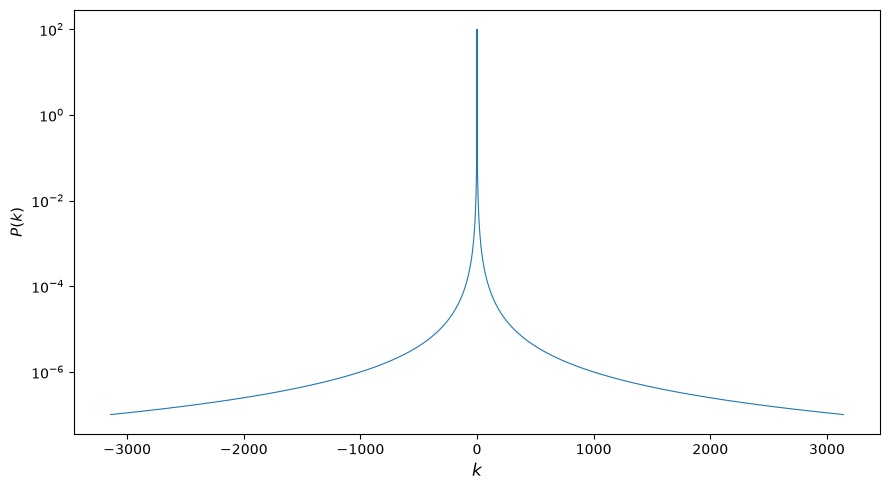

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def P(k, ep, N=2, abs=True):
    n = 1
    if abs:
        d = (np.abs(k) + ep) ** N
    else:
        d = (k + ep) ** N
    return n / d

SEED = 42
rng = np.random.default_rng(SEED)

N = 10000 # Samples
lb, rb = 0, 10 # Bounderies
L = rb - lb # Length of the box

real_space = np.linspace(lb, rb, N, endpoint=False)
dx = L / N # Spacing between samples

fourier_space_unshifted = 2 * np.pi * np.fft.fftfreq(N, d=dx)
fourier_space = np.fft.fftshift(fourier_space_unshifted)

Pk_unshifted = P(fourier_space_unshifted, ep=0.1)
Pk = np.fft.fftshift(Pk_unshifted)

plt.figure(figsize=(9, 5))
plt.plot(fourier_space, Pk, lw=0.8)
plt.yscale('log')
plt.ylabel('$P(k)$', fontsize=11)
plt.xlabel('$k$', fontsize=12)
plt.tight_layout()
plt.show()

### 1.1. Generate five realizations

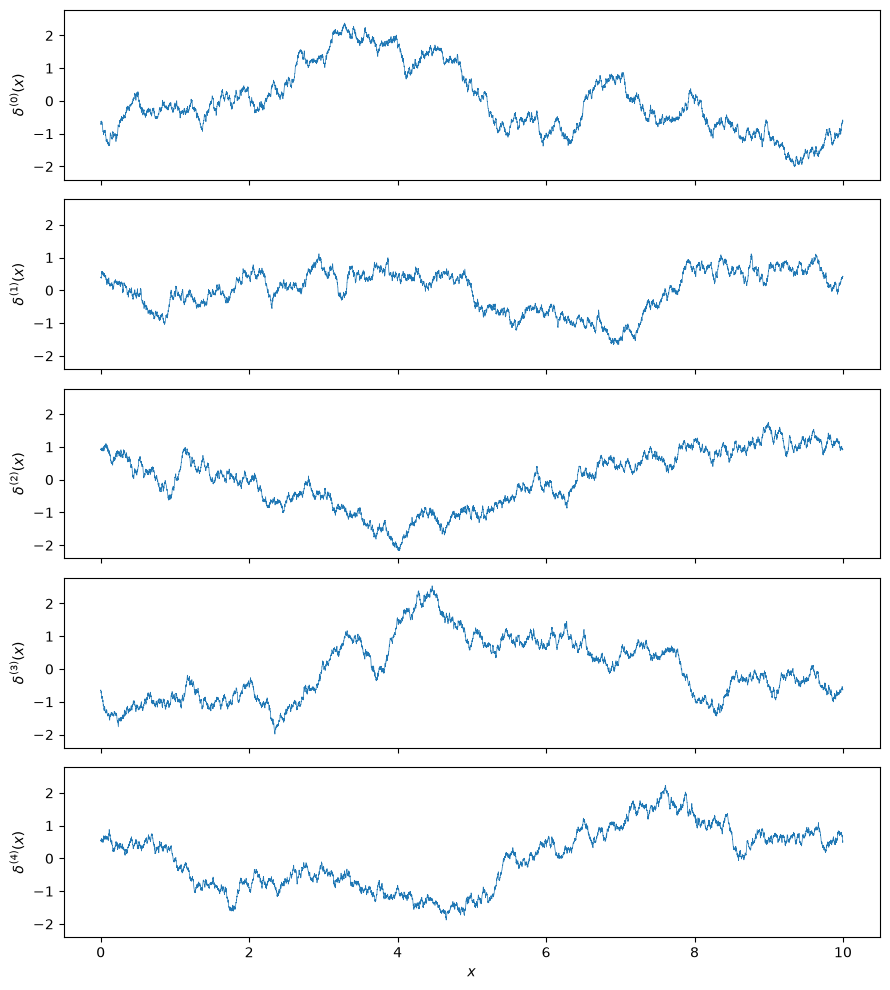

In [2]:
rng_childs = rng.spawn(5) # Childs

delta_k = np.empty((5, N), dtype=complex)
for i, g in enumerate(rng.spawn(5)):
    A = np.sqrt(N**2 * Pk_unshifted / L / 2) * (g.normal(size=N) + 1j * g.normal(size=N))
    A[0] = 0
    A[N//2] = np.sqrt(2) * A[N//2].real
    A[N//2+1:] = np.conj(A[1:N//2][::-1])
    delta_k[i] = A

delta_x = np.fft.ifft(delta_k, axis=1)

fig, axs = plt.subplots(5, 1, figsize=(9, 10), sharex=True, sharey=True)
for i, ax in enumerate(axs):
    ax.plot(real_space, delta_x[i].real, lw=0.5)
    ax.set_ylabel(rf'$\delta^{{({i})}}(x)$')
axs[-1].set_xlabel('$x$')
plt.tight_layout()
plt.show()

1. Sí, las realizaciones son diferentes.
2. Sí, todas parecen venir del mismo mecanismo: todas las realizaciones tienen la misma forma de "ruido plano" a lo largo de todo el intervalo.
3. Las amplitudes relativas parecen siempre las mismas, aunque las amplitudes globales no son claramente las mismas. También, todas parecen mantener la forma plana sin explitar en algún punto en contreto.

## 2. What condition makes the field real?

/tmp/ipykernel_124862/3006840040.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  delta_k_test[i] = A


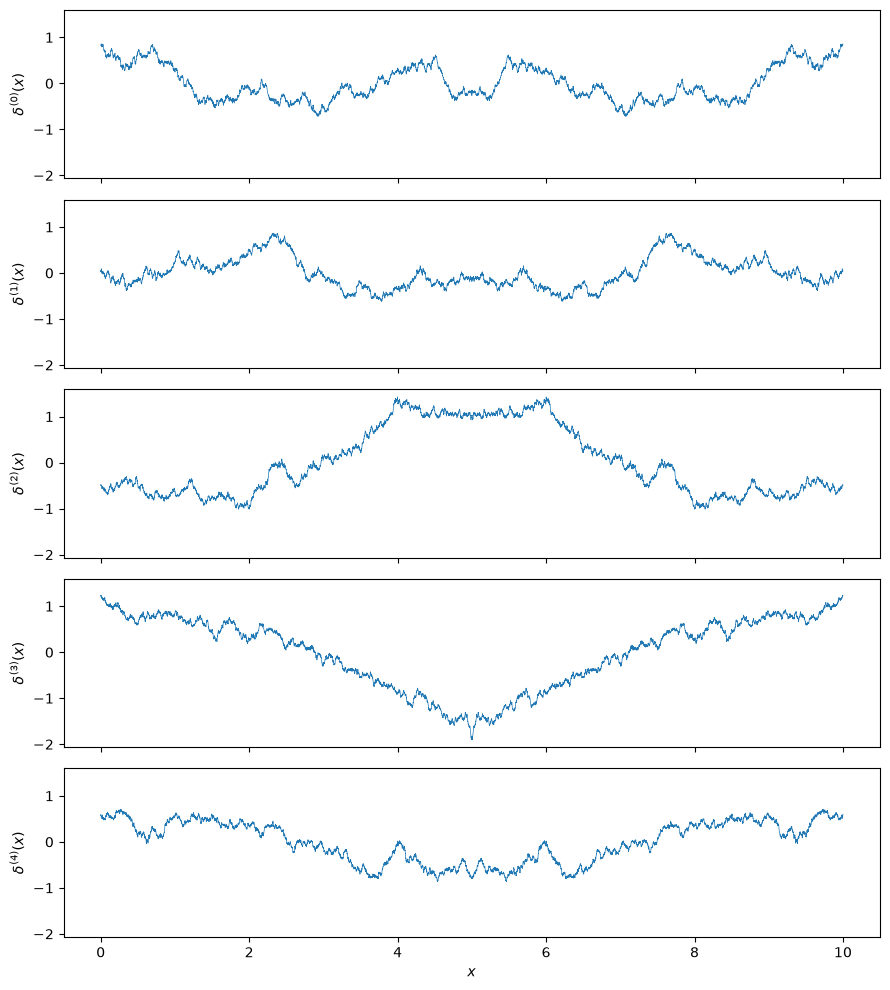

In [3]:
delta_k_test = np.empty((5, N))
for i, g in enumerate(rng.spawn(5)):
    A = np.sqrt(N ** 2 * Pk_unshifted / L / 2) * (g.normal(size=N) + 1j * g.normal(size=N))
    A[0] = 0
    A[N//2] = np.sqrt(2) * A[N//2].real
    delta_k_test[i] = A

delta_x_test = np.fft.ifft(delta_k_test, axis=1)

fig, axs = plt.subplots(5, 1, figsize=(9, 10), sharex=True, sharey=True)
for i, ax in enumerate(axs):
    ax.plot(real_space, delta_x_test[i].real, lw=0.5)
    ax.set_ylabel(rf'$\delta^{{({i})}}(x)$')
axs[-1].set_xlabel('$x$')
plt.tight_layout()
plt.show()

In [4]:
print(f"Condición de campo real (máx.): {np.max(delta_x.imag):.2e} \nSin condición (mín.): {np.min(delta_x_test.imag):.2e}")

Condición de campo real (máx.): 8.55e-16 
Sin condición (mín.): -1.17e+00


1. No, no es un campo real porque su parte imaginaria ya no es despreciable, ahora el orden de la parte imaginaria es de $\sim 1$.
2. Los ordenes de magnitud en la últimas realizaciones son similares, mientras que para las primeras las imaginarias son despreciables.
3. Para que el campo sea real se tiene que cumplir que $\delta_{-k} = (\delta_k)^*$.

Sobre la pregunta conceptual la respuesta es no, no es suficiente que si $\delta_k$ es real pura, entonces $\delta_x$ también lo será. Esto ocurre porque la transformada de Fourier es una transformación integral cuyo *kernel* es una exponencial imaginaria, por ende el resultado será imaginario para una función puramente real. Tampoco es suficiente que la función a transformar sea un simple número imaginario, como se ha visto en el ejercicio anterior, porque la transformación mapea de los complejos a los complejos. Es necesario que se cumpla una condición particular para mapear de los complejos a los reales dado por $f(-k) = f^*(k)$.

## 3. Same random phases, different power spectra

1. Como se está utilizando la misma forma funcional del espectro de potencias salvo una exponencial, entonces yo pe esperaría que $P_2(k)$ sea más suave porque va a ser aquella que tenga el pico menos pronunciado.
2. Ya que más $k$ va a contribuir a la formación del pico, entonces yo espero que $P_4(k)$ sea aquella realización con más estructura a pequeña escala. Después de otra leída, puede que me esté confundiendo con la estructura que representa el espectro a la estructura del propio espectro. Recordando de prácticas pasadas, la estructura a pequeña escala se concentra en los números de onda grandes, mientras que la estructura a gran escala se concentra en los números de onda pequeños. En este caso, entonces $P_2(k)$ debería expresar la mayor cantidad de estructura a pequeña escala.
3. Básicamente, la potencia de cada espectro está haciendo que las $k$ pequeñas formen el pico más rápido y que aquellas $k$ que pueden contribuir a expresar las escalas pequeñas no aporten a éste. De modo que, con cada aumento de la potencia del espectro, entonces cada vez se va a tener menor resolución a escalas pequeñas.

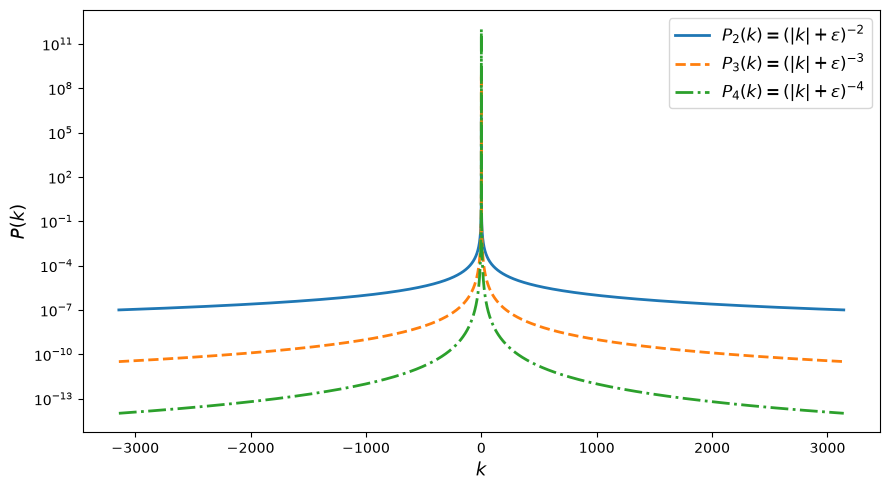

In [5]:
Pk_arr = np.asarray([P(fourier_space_unshifted, ep=0.001, N=i) for i in range(2, 5)])

plt.figure(figsize=(9, 5))
for n, Pn, ls in zip(range(2, 5), Pk_arr, ['-', '--', '-.']):
    plt.plot(fourier_space, np.fft.fftshift(Pn), ls, lw=2, label=rf'$P_{n}(k)=(|k|+\epsilon)^{{-{n}}}$')
plt.yscale('log')
plt.xlabel('$k$', fontsize=13)
plt.ylabel('$P(k)$', fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 3.1. Numerical comparation

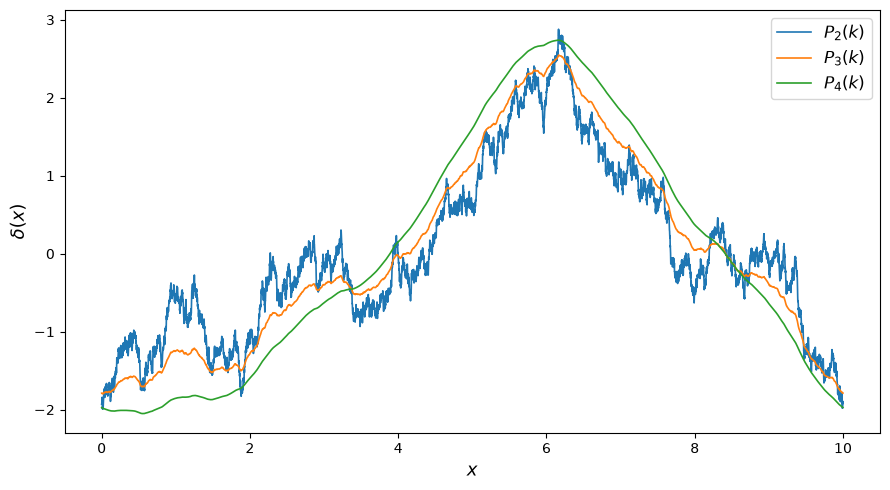

In [6]:
g = rng.spawn(1)[0]
a, b = g.normal(size=N), g.normal(size=N) # mismas fases para los tres P(k)

delta_k_three = np.empty((3, N), dtype=complex)
for i in range(3):
    A = np.sqrt(N ** 2 * Pk_arr[i] / L / 2) * (a + 1j * b)
    A[0] = 0
    A[N//2] = np.sqrt(2) * A[N//2].real
    A[N//2+1:] = np.conj(A[1:N//2][::-1])
    delta_k_three[i] = A

delta_x_three = np.fft.ifft(delta_k_three, axis=1)

plt.figure(figsize=(9, 5))
for n, d in zip(range(2, 5), delta_x_three):
    plt.plot(real_space, d.real, lw=1.2, label=f'$P_{n}(k)$')
plt.xlabel('$x$', fontsize=13)
plt.ylabel(r'$\delta(x)$', fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
ik = 1j * fourier_space_unshifted
ik[N//2] = 0
ddelta_x_three = np.asarray([np.fft.ifft(ik * delta_k_three[i]).real for i in range(3)])

prom_three = np.asarray([np.mean(ddelta_x_three[i] ** 2) for i in range(3)])

print(f"Promedio de las derivadas:")
print(f"P2: {prom_three[0]:.4f}")
print(f"P3: {prom_three[1]:.4f}")
print(f"P4: {prom_three[2]:.4f}")

Promedio de las derivadas:
P2: 991.3945
P3: 3.0037
P4: 1.1977


Creo que le he atinado a mi predicción en el sentido de que $P_2(k)$ representa aquella realización donde se puede observar mucho más la estructura a pequeña escala de $\delta(x)$. El resultado numérico está midiendo el cuadrado del ritmo de cambio del campo, así este no puede ser negativo, por lo que lo que se ve es una medida de los cambios punto a punto que sufre el campo a lo largo de todo el espacio. Un número más grande que otro representa, entonces, que este primer campo sufre más pequeños cambios de un punto a otro que uno que tiene un número más pequeño. $P_2(k)$ fue el que tuvo el mayor promedio, por lo que interpreto esto como el campo $\delta(x)$ que tuvo más resolución a escalas pequeñas y por ende más variación en su ritmo de cambio.

## 4. Fourier filter

Pues si estamos quitando todos los $|k|$ mayores a un cierto corte, entonces nos estamos deshaciendo de toda la estructura a pequeña escala. Yo esperaría ver una curva más suave.

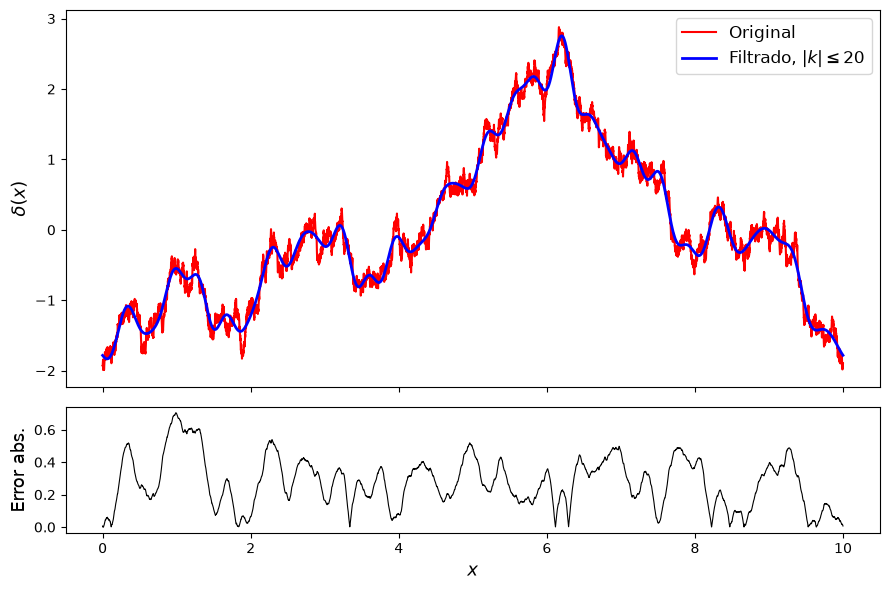

In [8]:
k_cut = 20

mask = np.abs(fourier_space_unshifted) > k_cut

delta_k_three_masked = np.where(mask, 0, delta_k_three[0])
delta_x_three_masked = np.fft.ifft(delta_k_three_masked)

fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[3, 1])
ax.plot(real_space, delta_x_three[0].real, c='r', label='Original')
ax.plot(real_space, delta_x_three_masked.real, c='b', lw=2, label=rf'Filtrado, $|k| \leq {k_cut}$')
ax.set_ylabel(r'$\delta(x)$', fontsize=13)
ax.legend(fontsize=12)
ax_err.plot(real_space, np.abs(delta_x_three[1].real - delta_x_three_masked.real), color='k', lw=0.8)
ax_err.set_xlabel('$x$', fontsize=13)
ax_err.set_ylabel('Error abs.', fontsize=13)
plt.tight_layout()
plt.show()

### 4.1. Remove large-scale modes

Ahora lo que va a ocurrir va a ser lo contrario a lo de antes: la estructura a gran escala es la que se va a terminar por desaparecer. Lo que yo espero que le ocurra al campo es que se aplane para que las amplitudes máximas y mínimas estén cerca del 0, mientras que se conservan los picos pequeño, algo así como si tomaramos la curva azul del ejercicio anterior y la estirasemos para que quede recta.

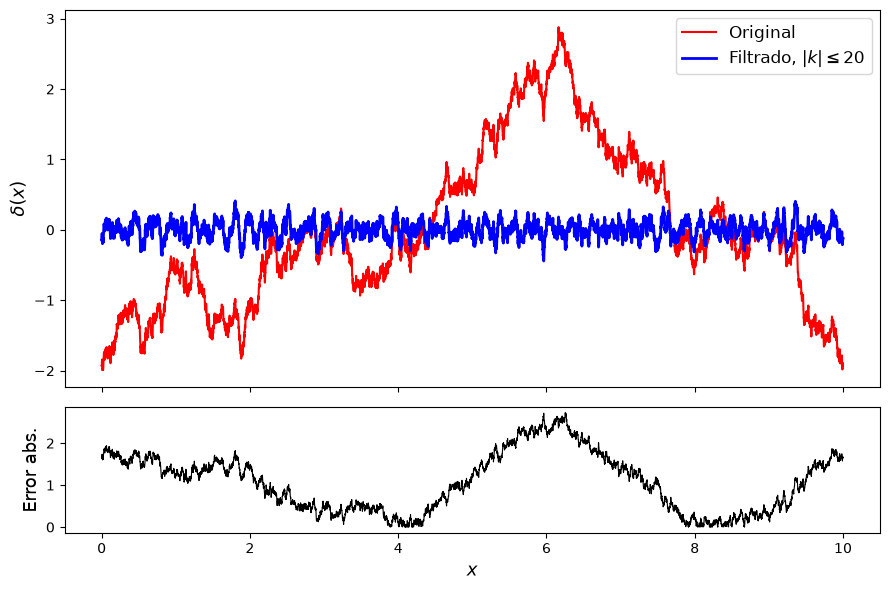

In [9]:
delta_k_three_masked = np.where(~mask, 0, delta_k_three[0])
delta_x_three_masked = np.fft.ifft(delta_k_three_masked)

fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[3, 1])
ax.plot(real_space, delta_x_three[0].real, c='r', label='Original')
ax.plot(real_space, delta_x_three_masked.real, c='b', lw=2, label=rf'Filtrado, $|k| \leq {k_cut}$')
ax.set_ylabel(r'$\delta(x)$', fontsize=13)
ax.legend(fontsize=12)
ax_err.plot(real_space, np.abs(delta_x_three[1].real - delta_x_three_masked.real), color='k', lw=0.8)
ax_err.set_xlabel('$x$', fontsize=13)
ax_err.set_ylabel('Error abs.', fontsize=13)
plt.tight_layout()
plt.show()

1. Los modos pequeños están asociados con la estructura a gran escala.
2. Los modos grandes están asociados con la estructura a pequeña escala.
3. El primer filtro, el que quita los modos grandes, remueve la estructura a pequeña escala, quitando ese "ruido" que sigue al patrón general de la curva; el segundo filtro, el de grandes escalas, comprime las amplitudes hasta dejarlas a todas cerca del cero, haciendo que ahora solo parezca ruido sobre una curva recta.

## 5. Gaussian random fields in two dimensions

In [10]:
N = 100
dx = L / N
kx_unshifted, ky_unshifted = 2 * np.pi * np.fft.fftfreq(N, d=dx), 2 * np.pi * np.fft.fftfreq(N, d=dx)
kx, ky = np.fft.fftshift(kx_unshifted), np.fft.fftshift(ky_unshifted)
X, Y = np.meshgrid(kx, ky)
k_mod_arr = np.hypot(X, Y)

Pk_iso = P(k_mod_arr, ep=0.1, abs=False)
Pk_iso_unshifted = np.fft.ifftshift(Pk_iso)

1. Si el espectro de potencia dependiera de $k_x$ o $k_y$ de forma separada, entonces rompería la isotropía, es decir, que el espectro variaría diferente dependiendo de la dirección la cuál se este estudiando.
2. En este punto la motivación a esta elección está dada por el principio cosmológico estadístico.
3. No, no puede ocurrir. Quizás pueda ocurrir si en pequeños desplazamientos, pero a gran escala no debe de influir ninguna dirección.

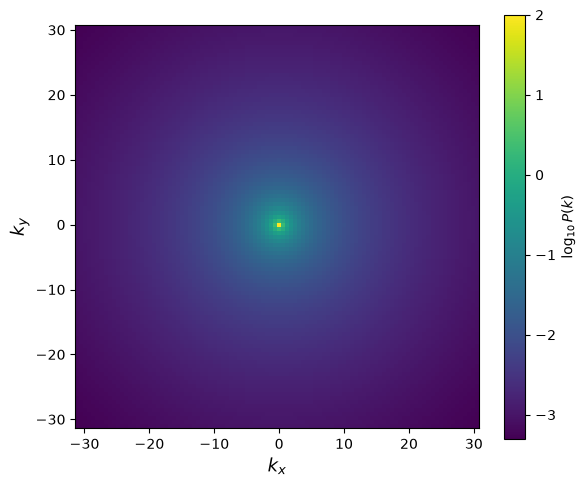

In [11]:
plt.figure(figsize=(6, 5))
plt.imshow(np.log10(Pk_iso), origin='lower', extent=[kx[0], kx[-1], ky[0], ky[-1]])
plt.colorbar(label=r'$\log_{10} P(k)$')
plt.xlabel('$k_x$', fontsize=13)
plt.ylabel('$k_y$', fontsize=13)
plt.tight_layout()
plt.show()

### 5.1. Generate five 2D realizations

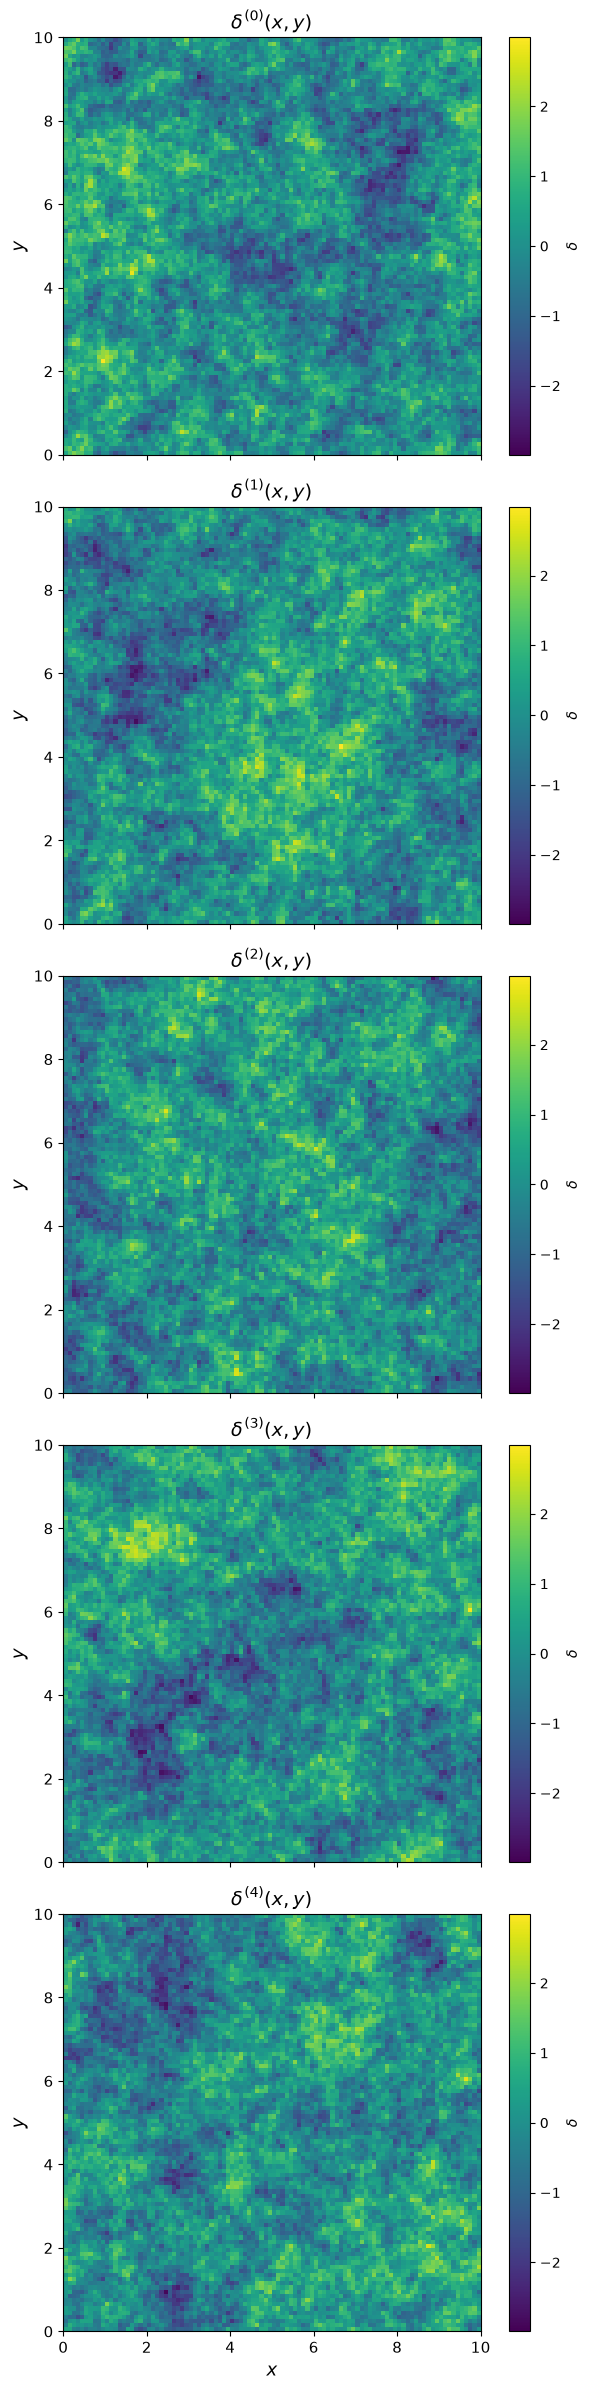

In [ ]:
flip = lambda A: np.roll(A[::-1, ::-1], 1, axis=(0, 1)) # A[-i, -j] con índices periódicos

delta_k_2d = np.empty((5, N, N), dtype=complex)
for i, g in enumerate(rng.spawn(5)):
    A = np.sqrt(N**4 * Pk_iso_unshifted / L ** 2 / 2) * (g.normal(size=(N, N)) + 1j * g.normal(size=(N, N)))
    A = (A + np.conj(flip(A))) / np.sqrt(2) # delta(-k) = conj(delta(k))
    A[0, 0] = 0
    delta_k_2d[i] = A

delta_x_2d = np.fft.ifft2(delta_k_2d)

vmax = np.abs(delta_x_2d.real).max()
fig, axs = plt.subplots(5, 1, figsize=(6, 24), sharex=True)
for i, ax in enumerate(axs):
    im = ax.imshow(delta_x_2d[i].real, origin='lower', extent=[0, L, 0, L], vmin=-vmax, vmax=vmax)
    ax.set_title(rf'$\delta^{{({i})}}(x, y)$', fontsize=14)
    ax.set_ylabel('$y$', fontsize=13)
    ax.tick_params(labelsize=11)
    fig.colorbar(im, ax=ax, label=r'$\delta$')
axs[-1].set_xlabel('$x$', fontsize=13)
plt.tight_layout()
plt.show()

Ok, el algoritmo para conseguir la condición de realidad está un poco complicada, pero la animación ayuda a que sea fácil de entender.

Obviamente que las sobredensidades están ubicadas en lugares distintos, pero esto era esperado. Se alcanza a ver que todo está alrededor del cero, así que están bien distribuídas.